In [9]:
import argparse
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

In [21]:
def convert_to_csv(input_file, output_file="wine.csv"):
    columns = [
        "class", "alcohol", "malic_acid", "ash", "alcalinity_of_ash",
        "magnesium", "total_phenols", "flavanoids", "nonflavanoid_phenols",
        "proanthocyanins", "color_intensity", "hue",
        "od280/od315_of_diluted_wines", "proline"
    ]

    df = pd.read_csv(input_file, header=None, names=columns)
    df.to_csv(output_file, index=False)

    print("CSV created:", output_file)
    return df

# Run conversion
df = convert_to_csv("wine.data")
df.head()

CSV created: wine.csv


,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [22]:
X = df.drop(columns=["class"])
y = df["class"]

print(X.shape, y.shape)

(178, 13) (178,)


In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
def evaluate_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    return acc, f1

acc_orig, f1_orig = evaluate_model(X_scaled, y)

print("Original Data:")
print("Accuracy:", acc_orig)
print("F1 Score:", f1_orig)

Original Data:
Accuracy: 0.9722222222222222
F1 Score: 0.9719701552732407


In [28]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

df_lda = pd.DataFrame(X_lda, columns=["LD1", "LD2"])
df_lda["Class"] = y.values
df_lda["SampleId"] = np.arange(len(df_lda))

# Correct column order
df_lda = df_lda[["SampleId", "LD1", "LD2", "Class"]]

df_lda.to_csv("lda_projection.csv", index=False)

print("Saved: lda_projection.csv")
df_lda.head()

Saved: lda_projection.csv


,SampleId,LD1,LD2,Class
0,0,-4.700244,1.979138,1
1,1,-4.301958,1.170413,1
2,2,-3.420720,1.429101,1
3,3,-4.205754,4.002871,1
4,4,-1.509982,0.451224,1


In [29]:
print("\n--- Classification Comparison ---")
print(f"Original Data -> Accuracy: {acc_orig:.4f}, F1: {f1_orig:.4f}")
print(f"LDA (1D)     -> Accuracy: {acc_lda1:.4f}, F1: {f1_lda1:.4f}")
print(f"LDA (2D)     -> Accuracy: {acc_lda2:.4f}, F1: {f1_lda2:.4f}")


--- Classification Comparison ---
Original Data -> Accuracy: 0.9722, F1: 0.9720
LDA (1D)     -> Accuracy: 0.8889, F1: 0.8885
LDA (2D)     -> Accuracy: 1.0000, F1: 1.0000


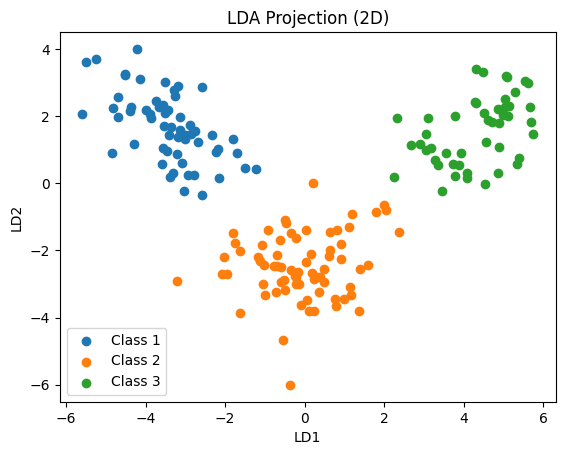

In [27]:
import matplotlib.pyplot as plt

plt.figure()

for label in np.unique(y):
    plt.scatter(
        X_lda2[y == label, 0],
        X_lda2[y == label, 1],
        label=f"Class {label}"
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection (2D)")
plt.legend()
plt.show()

### Interpretation

LDA is a supervised dimensionality reduction technique that uses class labels, unlike PCA which is unsupervised. It maximizes between-class variance and minimizes within-class variance.

After projection to 2D, the wine classes are clearly separated, showing strong class separability. In 1D, separation exists but is less distinct.

Classification performance using Logistic Regression remains high after LDA, sometimes improving slightly due to noise reduction.

LDA is limited to (number of classes − 1) components, which is 2 for this dataset. It is more suitable than PCA when the goal is classification.